ambiente:

conda activate Udemy


### Tópico, seleção de atributos.

Podemos enviar a base completa para o algoritmo

nem sempre quando temos uma quantidade maior de atributos teremos melhores resultados.

Executar operações, para selecionar os melhores atributos.

Como são mais de 500, algoritmos podemos processar com 200, e o tempo de aprendizagem de máquina melhora, além do desempenho. 

### 28.8) Seleção de atributos

### Preparação da base de dados

In [86]:
import pandas as pd
base_census = pd.read_csv('../24-Dados_desbalanceados/census.csv')
base_census.tail()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [87]:
base_census.columns

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country',
       'income'],
      dtype='object')

In [88]:
len(base_census.columns)

15

atributos previsores, 

e o que devemos prever é o income (ou a renda)

In [89]:
base_census["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [90]:
colunas = base_census.columns[:-1]
colunas # só as colunas que ajudam a fazer a previsão do income

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country'],
      dtype='object')

In [91]:
base_census.columns[0:14]

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country'],
      dtype='object')

In [92]:
base_census.columns[14]

'income'

In [93]:
X_census = base_census.iloc[:, 0:14].values
y_census = base_census.iloc[:, 14].values

### transformar os atributos categóricos em um formato numérico, para isso vamos usar o label_encoder para cada um dos atributos

In [94]:
X_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      shape=(32561, 14), dtype=object)

In [95]:
y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      shape=(32561,), dtype=object)

In [96]:
X_census[:5]

array([[39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married',
        ' Adm-clerical', ' Not-in-family', ' White', ' Male', 2174, 0,
        40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ' Bachelors', 13,
        ' Married-civ-spouse', ' Exec-managerial', ' Husband', ' White',
        ' Male', 0, 0, 13, ' United-States'],
       [38, ' Private', 215646, ' HS-grad', 9, ' Divorced',
        ' Handlers-cleaners', ' Not-in-family', ' White', ' Male', 0, 0,
        40, ' United-States'],
       [53, ' Private', 234721, ' 11th', 7, ' Married-civ-spouse',
        ' Handlers-cleaners', ' Husband', ' Black', ' Male', 0, 0, 40,
        ' United-States'],
       [28, ' Private', 338409, ' Bachelors', 13, ' Married-civ-spouse',
        ' Prof-specialty', ' Wife', ' Black', ' Female', 0, 0, 40,
        ' Cuba']], dtype=object)

In [97]:
base_census.columns[0:14]

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country'],
      dtype='object')

In [98]:
from sklearn.preprocessing import LabelEncoder
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_marital.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [99]:
X_census

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object)

### sem string e com números

### temos que normalizar os dados 

In [100]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_census_scaler = scaler.fit_transform(X_census)
X_census_scaler # dados padronizados

array([[0.30136986, 0.875     , 0.0443019 , ..., 0.        , 0.39795918,
        0.95121951],
       [0.45205479, 0.75      , 0.0482376 , ..., 0.        , 0.12244898,
        0.95121951],
       [0.28767123, 0.5       , 0.13811345, ..., 0.        , 0.39795918,
        0.95121951],
       ...,
       [0.56164384, 0.5       , 0.09482688, ..., 0.        , 0.39795918,
        0.95121951],
       [0.06849315, 0.5       , 0.12849934, ..., 0.        , 0.19387755,
        0.95121951],
       [0.47945205, 0.625     , 0.18720338, ..., 0.        , 0.39795918,
        0.95121951]], shape=(32561, 14))

Seleção de atributos, com base na variância

# 28.9) verificar as colunas ou atributos mais importantes para prever o income (renda)

## Seleção com low variance

Validação de algoritmo

### Low variance

## _Variância: medida de dispersão estatística vai indicar o quanto os dados variam com a relação à média, quanto mais afastado da média maior é a variância._

In [101]:
X_census_scaler.shape

(32561, 14)

In [102]:
X_census.shape # tamanho da base

(32561, 14)

In [103]:
X_census.shape[1] # quantidade de colunas/atributos

14

In [104]:
X_census.shape[0] # linhas 

32561

In [105]:
base_census.columns[0]

'age'

In [106]:
# todos os valores da primeira coluna, idade
X_census[:,0]


array([39, 50, 38, ..., 58, 22, 52], shape=(32561,), dtype=object)

In [107]:
# idades reais e idades escalonadas
X_census[:,0], X_census_scaler[:,0]

(array([39, 50, 38, ..., 58, 22, 52], shape=(32561,), dtype=object),
 array([0.30136986, 0.45205479, 0.28767123, ..., 0.56164384, 0.06849315,
        0.47945205], shape=(32561,)))

In [108]:
X_census[:,0].mean(), X_census_scaler[:,0].mean()# média

(np.float64(38.58164675532078), np.float64(0.2956389966482299))

In [109]:
# quantos registros estão afastados da média e com relação à variância dos dados escalonados
X_census[:,0].var(), X_census_scaler[:,0].var()

(np.float64(186.0556860078255), np.float64(0.034913808595952486))

In [110]:
# desvio padrão
import numpy as np
np.sqrt(X_census[:,0].var()), X_census_scaler[:,0].var()

(np.float64(13.640223092304081), np.float64(0.034913808595952486))

In [111]:
# na idade os dados estão afastado em torno de 13, com relação à média. tendo 13 anos para baixo ou para cima.

# o método neste caso utiliza apenas a variância, não o desvio padrão

In [112]:
for i in range(X_census.shape[1]):
   print(f"Atributo {i+1}: {base_census.columns[i]}")
   print(f"Variância do atributo, ou extração da variância: {X_census[:,i].var():.2f}")
   #print("Variância escalonada")
   if X_census_scaler[:,i].var() > 0.05:
       # Verde
       print(f"Variância do atributo escalonado ({base_census.columns[i]}): \033[32m{X_census_scaler[:,i].var():.5f}\033[0m")       
   else:        
       print(f"Variância do atributo escalonado ({base_census.columns[i]}): {X_census_scaler[:,i].var():.5f}")
   print()

    
# \033[92m → verde
# \033[0m → volta à cor normal
# \033[32m → verde

Atributo 1: age
Variância do atributo, ou extração da variância: 186.06
Variância do atributo escalonado (age): 0.03491

Atributo 2: workclass
Variância do atributo, ou extração da variância: 2.12
Variância do atributo escalonado (workclass): 0.03312

Atributo 3: final-weight
Variância do atributo, ou extração da variância: 11140455640.26
Variância do atributo escalonado (final-weight): 0.00514

Atributo 4: education
Variância do atributo, ou extração da variância: 14.98
Variância do atributo escalonado (education): 0.06657

Atributo 5: education-num
Variância do atributo, ou extração da variância: 6.62
Variância do atributo escalonado (education-num): 0.02942

Atributo 6: marital-status
Variância do atributo, ou extração da variância: 2.27
Variância do atributo escalonado (marital-status): 0.06302

Atributo 7: occupation
Variância do atributo, ou extração da variância: 17.88
Variância do atributo escalonado (occupation): 0.09124

Atributo 8: relationship
Variância do atributo, ou extr

## 📌 Variância (Variance)

$\[
\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2
\]$

Fórmula da variância que o NumPy usa:

𝑥𝑖 = valor individual

𝜇 = média da coluna

𝑛 = número de elementos

## 📌 Desvio Padrão (Standard Deviation)

$\[
\sigma = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_i - \mu)^2}
\]$

Aplica raiz quadrada sobre a variância → isso vira o desvio padrão.

Ou seja:

variância → raiz → desvio padrão

valores muito baixos de variância está mais próximo da média

In [113]:
# contextualizar a variância

# salário pode ser anual/mensal e renda pode ser anual/mensal, tem que verificar. 
# salário - renda = parecidos
# idade - gênero = diferentes
# ATRIBUTos diferentes terão variâncias diferentes.


### foram selecionados somente 5 atributos que possuem um valor maior que 0,05

In [114]:
from sklearn.feature_selection import VarianceThreshold

selecao = VarianceThreshold(threshold=0.05) # valor da variância mínima, atributos com variância significativa (0,05)
X_census_variancia = selecao.fit_transform(X_census_scaler)
X_census_variancia.shape


(32561, 5)

In [115]:

X_census_variancia # apenas 5 variâncias

array([[0.6       , 0.66666667, 0.07142857, 0.2       , 1.        ],
       [0.6       , 0.33333333, 0.28571429, 0.        , 1.        ],
       [0.73333333, 0.        , 0.42857143, 0.2       , 1.        ],
       ...,
       [0.73333333, 1.        , 0.07142857, 0.8       , 0.        ],
       [0.73333333, 0.66666667, 0.07142857, 0.6       , 1.        ],
       [0.73333333, 0.33333333, 0.28571429, 1.        , 0.        ]],
      shape=(32561, 5))

In [116]:
selecao.variances_ # valores das variâncias => são os mesmos valores calculados "manualmente"
# inidicios dos atributos selecionados

array([0.03491381, 0.03312115, 0.00513854, 0.06657104, 0.02941639,
       0.06301762, 0.09123817, 0.10326534, 0.04502805, 0.2213695 ,
       0.0054542 , 0.00855727, 0.01587404, 0.03641266])

In [117]:
# verificar os indices selecionados
indices = np.where(selecao.variances_ > 0.05) # precisa ser o mínimio da variãncia selecionado "threshold"
indices

(array([3, 5, 6, 7, 9]),)

In [118]:
#colunas

In [119]:
colunas[indices] # indices selecionados

Index(['education', 'marital-status', 'occupation', 'relationship', 'sex'], dtype='object')

## Treinamento das colunas classificadas e vamos comparar seus resultados, se serão ou não melhores com a base de dados completas

In [120]:
# para o processo deletaremos as colunas que não foram selecionadas na variância maior que 0,05
base_census_variancia = base_census.drop(columns = ['age', 'workclass', 'final-weight',
                                                    'education-num', 'race', 'capital-gain',
                                                    'capital-loos', 'hour-per-week',
                                                    'native-country'], axis = 1) # axis = 1 apaga as colunas
base_census_variancia.tail(20) # estas bases de dados para fazer a previsão

,education,marital-status,occupation,relationship,sex,income
32541,HS-grad,Separated,?,Not-in-family,Female,<=50K
32542,HS-grad,Married-civ-spouse,?,Husband,Male,<=50K
32543,Assoc-acdm,Divorced,Prof-specialty,Unmarried,Female,<=50K
32544,Masters,Divorced,Other-service,Not-in-family,Female,<=50K
32545,Assoc-acdm,Married-civ-spouse,Adm-clerical,Wife,Female,>50K
32546,Assoc-acdm,Divorced,Tech-support,Not-in-family,Female,<=50K
32547,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,Male,<=50K
32548,Prof-school,Never-married,Prof-specialty,Not-in-family,Male,<=50K
32549,Some-college,Divorced,Adm-clerical,Other-relative,Female,<=50K
32550,Some-college,Married-civ-spouse,Craft-repair,Husband,Male,<=50K


In [121]:
# iloc[todas as linhas, colunas de 0 à 5]
X_census_variancia = base_census_variancia.iloc[:,0:5].values
# iloc[todas as linhas, colunas 5 : só a income renda]
y_census_variancia = base_census_variancia.iloc[:,5].values

In [122]:
X_census_variancia[:1]

array([[' Bachelors', ' Never-married', ' Adm-clerical',
        ' Not-in-family', ' Male']], dtype=object)

In [123]:
X_census_variancia

array([[' Bachelors', ' Never-married', ' Adm-clerical',
        ' Not-in-family', ' Male'],
       [' Bachelors', ' Married-civ-spouse', ' Exec-managerial',
        ' Husband', ' Male'],
       [' HS-grad', ' Divorced', ' Handlers-cleaners', ' Not-in-family',
        ' Male'],
       ...,
       [' HS-grad', ' Widowed', ' Adm-clerical', ' Unmarried', ' Female'],
       [' HS-grad', ' Never-married', ' Adm-clerical', ' Own-child',
        ' Male'],
       [' HS-grad', ' Married-civ-spouse', ' Exec-managerial', ' Wife',
        ' Female']], shape=(32561, 5), dtype=object)

In [124]:
y_census_variancia

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      shape=(32561,), dtype=object)

## Faremos agora o pré-processamento de dados


In [125]:
X_census_variancia[:,0] = label_encoder_education.fit_transform(X_census_variancia[:,0])
X_census_variancia[:,1] = label_encoder_marital.fit_transform(X_census_variancia[:,1])
X_census_variancia[:,2] = label_encoder_occupation.fit_transform(X_census_variancia[:,2])
X_census_variancia[:,3] = label_encoder_relationship.fit_transform(X_census_variancia[:,3])
X_census_variancia[:,4] = label_encoder_sex.fit_transform(X_census_variancia[:,4])

In [126]:
X_census_variancia

array([[9, 4, 1, 1, 1],
       [9, 2, 4, 0, 1],
       [11, 0, 6, 1, 1],
       ...,
       [11, 6, 1, 4, 0],
       [11, 4, 1, 3, 1],
       [11, 2, 4, 5, 0]], shape=(32561, 5), dtype=object)

In [127]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer  
# número das colunas para o one hot encoder
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [0,1,2,3,4])],remainder='passthrough')
X_census_variancia = onehotencorder.fit_transform(X_census_variancia).toarray()
X_census_variancia

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(32561, 46))


LabelEncoder transforma string em número

normalizar os dados MinMaxScaler
  

In [128]:
scaler = MinMaxScaler()
X_census_variancia = scaler.fit_transform(X_census_variancia)
X_census_variancia

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(32561, 46))

🔹 LabelEncoder – transforma categorias em números inteiros

cores = ['vermelho', 'azul', 'verde']

Ele pega cada valor categórico e transforma em um número:

Original:LabelEncoder
vermelho:2
azul:0
verde:1


🔹 OneHotEncoder – cria colunas binárias (0 e 1)

Em vez de um número único, ele cria uma coluna para cada categoria:

Exemplo:
Cor	azul	verde	vermelho
azul	1	0	0
verde	0	1	0
vermelho0	0	1



### _Quando usar cada um?_

Categorias sem ordem (ex: cor, cidade, sexo) =>	OneHotEncoder

Categorias com ordem real (ex: pequeno, médio, grande)	=> LabelEncoder ou OrdinalEncoder


LabelEncoder = transforma texto em um número (pode induzir ordem errada)

OneHotEncoder = cria várias colunas 0/1 sem criar ordem

## dividir o treinamento e o teste

In [129]:
from sklearn.model_selection import train_test_split
X_census_treinamento_var, X_census_teste_var, y_census_treinamento_var, y_census_teste_var = train_test_split(X_census_variancia, y_census_variancia, test_size=0.15, random_state=0)
X_census_treinamento_var.shape, X_census_teste_var.shape

((27676, 46), (4885, 46))

In [130]:
# 84.70
from sklearn.ensemble import RandomForestClassifier
random_forest_var = RandomForestClassifier(criterion = 'entropy', min_samples_leaf =  1, min_samples_split = 5, n_estimators = 100)
random_forest_var.fit(X_census_treinamento_var, y_census_treinamento_var)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
random_forest_var.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [132]:
from sklearn.metrics import accuracy_score, classification_report
previsoes = random_forest_var.predict(X_census_teste_var)
accuracy_score(y_census_teste_var, previsoes)


0.818014329580348

In [133]:
acuracia = accuracy_score(y_census_teste_var, previsoes)

In [134]:
print(f'Acurácia do random forest utilizando o método da variância {acuracia*100:.2f} %')

Acurácia do random forest utilizando o método da variância 81.80 %


In [135]:
# acurácia do modelo (arquivo census.csv

# a acurácia, lembrando que no 2-Naive_Bayes_Bayesiano.ipynb, método bayesiano a acurácia era de apenas 47,68% no census
# a acurácia, lembrando que no 3-3_Arvore_decision_Census_parte4.ipynb, método da árvore de decisão simples a acurácia era de 81,04% no census
# a acurácia, lembrando que no 3-5_Arvore_decision_Random_Forest_Census.ipynb método das múltiplas árvores
# => A acurácia do modelo é de 85.08% para 100 árvores (n_estimators).


# a acurácia, lembrando que no 4-4_InducaodeRegras_BaseCEnsus.ipynb, método das regras => Acurácia do modelo 75.92 %

# Acurácia da instância KNN 82.23 % com 5 vizinhos próximos
# Acurácia da instância KNN 82.91 % ideal 10 vizinhos próximos, 5-2AprendizagemKNN_BaseCensus.ipynb

#Acurácia da Regressão Logística 84.97 %, 6-3RegressaoLogistica_BaseCensus.ipynb

#Acurácia da SVM - Support Vector Machine 85.08 %, para Kernel: linear e C: 1.0 , 7-2_SVM_Supporte_Vector_Machine_Base_census.ipynb


#A acurácia deep learning é de 81.56%, hidden_layer_sizes = (55,55))


# acurácia desbalanceados M26-3-desbalanceados_Sobreamostragem_SMOTE.ipynb
# A acurácia do modelo é de 89.02% para 100 árvores (n_estimators).

#-------------------------
#naive bayes - tabela de probabilidade

#árvore de decisão - estrutura de dados

#regras - gera regras e classificar

#instância Knn- vizinhos mais próximos, e calcula as distâncias (armazena os dados)

#regressão logistica - melhor curva possível para classificar os registros 

#algoritmo SVM - encontrar uma linha com a margem máxima

#redes neurais - deep learning



In [136]:
## algoritmo extra trees

### 29.0) Extra tree

- Random Forest x Extra Trees Classifier: https://www.thekerneltrip.com/statistics/random-forest-vs-extra-tree/

#### Random Forest: seleção de atributos, além de usar para classificação

#### Extra Trees semelhante ao Random Forest, faremos a seleção de atributos

In [137]:
from sklearn.ensemble import ExtraTreesClassifier

In [138]:
X_census_scaler.shape

(32561, 14)

In [139]:
print(f'Linhas ou registros são de {X_census_scaler.shape[0]} e atributos são de {X_census_scaler.shape[1]}')

Linhas ou registros são de 32561 e atributos são de 14



https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html


class sklearn.ensemble.ExtraTreesClassifier ( n_estimators = 100 , * , criterion = ' gini' , max_depth = None , min_samples_split = 2 , min_samples_leaf = 1 , min_weight_fraction_leaf = 0.0 , max_features = 'sqrt' , max_leaf_nodes = None , min_impurity_decrease = 0.0 , bootstrap = False , oob_score = False , n_jobs = None , random_state = None , verbose = 0 , warm_start = False , class_weight = None , ccp_alpha = 0.0 , max_samples = None , monotonic_cst = None )


n_estimador = número de árvores na floresta

critério {“gini”, “entropia”, “log_loss”}, padrão=”gini”
A função para medir a qualidade de uma divisão. Os critérios suportados são “gini” para a impureza de Gini e “log_loss” e “entropy”, ambos para o ganho de informação de Shannon, veja Formulação matemática . Nota: Este parâmetro é específico da árvore.



In [140]:
selecao = ExtraTreesClassifier()

In [141]:
# treinaremos com a base de dados inteira

selecao.fit(X_census_scaler, y_census) # treinar o algoritmo basedados em todos os dados

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [142]:
selecao.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

- parâmetro: n_estimators, Tipo:Quantidade =>	Número de árvores na floresta. O padrão é 100. Aumentar este valor geralmente melhora a precisão, mas aumenta o tempo de treinamento.


- criterion, Estratégia =>	Função para medir a qualidade de uma divisão (split). O padrão é 'gini' (Gini Impurity). Alternativa comum: 'entropy' (Entropia).

- max_depth,	Estrutura	=> Profundidade máxima de cada árvore. None (Padrão) significa que os nós são expandidos até que todas as folhas sejam puras (contendo apenas uma classe) ou até que a condição min_samples_split seja atingida.

- min_samples_split, Estrutura	=> Número mínimo de amostras necessárias para dividir um nó interno. O padrão é 2. Valores maiores evitam o overfitting.

- min_samples_leaf,	Estrutura =>	Número mínimo de amostras que deve ter um nó folha. O padrão é 1. Garante que as folhas não sejam muito pequenas, o que ajuda a generalizar.

- max_features,	Aleatoriedade	=> Número de features (variáveis) a considerar para a melhor divisão. No ExtraTrees, o padrão é 'sqrt' (raiz quadrada do total de features), pois a aleatoriedade é o núcleo deste modelo.

- bootstrap, Amostragem	=> Se as amostras de treino são retiradas com substituição. Padrão: False (diferente do Random Forest, que usa True). ExtraTrees geralmente usa o conjunto de dados completo.

- oob_score,	Avaliação =>	Se deve usar amostras out-of-bag (não usadas na construção da árvore) para estimar a precisão de generalização. Padrão: False. Requer bootstrap=True para funcionar.

- random_state,	Reprodução =>	Semente para o gerador de números aleatórios. Definir um valor (ex: 42) garante que os resultados sejam os mesmos a cada execução.

- n_jobs,	Processamento=> Número de jobs (núcleos do processador) a serem usados em paralelo. None significa 1. -1 usa todos os núcleos disponíveis (acelera o treinamento).

In [143]:
# conteúdo das variáveis
importancias = selecao.feature_importances_
importancias

array([0.1552388 , 0.04433268, 0.16485218, 0.03603824, 0.09043419,
       0.07423258, 0.07520167, 0.08886385, 0.01428013, 0.02929678,
       0.08858164, 0.02812997, 0.09330416, 0.01721313])

In [144]:
len(colunas)

14

In [145]:
colunas

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country'],
      dtype='object')

In [146]:

print('Colunas com as maiores importâncias')
for col in  range(len(colunas)):
    if importancias[col]> 0.08:
       print(f'{colunas[col]}: {importancias[col]}')   

    

Colunas com as maiores importâncias
age: 0.15523880252363775
final-weight: 0.164852183995789
education-num: 0.09043418915212673
relationship: 0.08886384655775169
capital-gain: 0.08858163868528283
hour-per-week: 0.09330415932323374


comparar as técnicas por variância e importância. além de fazer testes e comparar os resultados.

In [147]:
importancias.sum() # o ideal é ser 100%

np.float64(1.0)

In [148]:
print('considerar a coluna com maior importância')
indices = []
for i in range(len(importancias)):
  print(f'{colunas[i]}: {importancias[i]}') 
  if importancias[i] >= 0.029:
    indices.append(i)

considerar a coluna com maior importância
age: 0.15523880252363775
workclass: 0.044332683172954836
final-weight: 0.164852183995789
education: 0.036038238515697395
education-num: 0.09043418915212673
marital-status: 0.07423258372200683
occupation: 0.07520166720549433
relationship: 0.08886384655775169
race: 0.014280131174181416
sex: 0.029296779853878654
capital-gain: 0.08858163868528283
capital-loos: 0.02812996959221694
hour-per-week: 0.09330415932323374
native-country: 0.017213126525747958


In [149]:
len(indices)

11

In [150]:
indices

[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 12]

In [151]:
# nome das colunas ou atributos selecionados
colunas[indices]

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'sex', 'capital-gain',
       'hour-per-week'],
      dtype='object')

## novo numpy array com os novos índices selecionados

In [152]:
X_census_extra = X_census[:, indices]
X_census_extra

array([[39, 7, 77516, ..., 1, 2174, 40],
       [50, 6, 83311, ..., 1, 0, 13],
       [38, 4, 215646, ..., 1, 0, 40],
       ...,
       [58, 4, 151910, ..., 0, 0, 40],
       [22, 4, 201490, ..., 1, 0, 20],
       [52, 5, 287927, ..., 0, 15024, 40]],
      shape=(32561, 11), dtype=object)

In [153]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [1,3,5,6,7])],remainder='passthrough')
X_census_extra = onehotencorder.fit_transform(X_census_extra).toarray()
X_census_extra

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 2.1740e+03,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        1.3000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 0.0000e+00,
        2.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.5024e+04,
        4.0000e+01]], shape=(32561, 59))

In [154]:
X_census_extra.shape

(32561, 59)

In [155]:
from sklearn.model_selection import train_test_split
X_census_treinamento_extra, X_census_teste_extra, y_census_treinamento_extra, y_census_teste_extra = train_test_split(X_census_extra, y_census, test_size=0.15, random_state=0)
X_census_treinamento_extra.shape, X_census_teste_extra.shape  #treinamento/teste

((27676, 59), (4885, 59))

# faremos agora a classificação com o random forecast

In [156]:
from sklearn.ensemble import RandomForestClassifier
random_forest_extra = RandomForestClassifier(criterion = 'entropy', min_samples_leaf =  1, min_samples_split = 5, n_estimators = 100)
random_forest_extra.fit(X_census_treinamento_extra, y_census_treinamento_extra)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [157]:
random_forest_extra.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [158]:
# 0.8470
from sklearn.metrics import accuracy_score, classification_report
previsoes = random_forest_extra.predict(X_census_teste_extra)
accuracy_score(y_census_teste_extra, previsoes)

0.8479017400204708

In [159]:
acuracia_2 = accuracy_score(y_census_teste_extra, previsoes)

In [161]:
print(f'Acurácia do random forest utilizando o método da importância nos atributos: {acuracia_2*100:.2f} %')

Acurácia do random forest utilizando o método da importância nos atributos: 84.79 %


In [162]:
# somente 59 colunas, para analise atual

In [163]:
np.unique(y_census, return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

In [165]:
from sklearn.metrics import confusion_matrix


In [166]:
#X_census_treinamento_extra, X_census_teste_extra, y_census_treinamento_extra, y_census_teste_extra
conf_matrix = confusion_matrix(y_census_teste_extra, previsoes)

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns


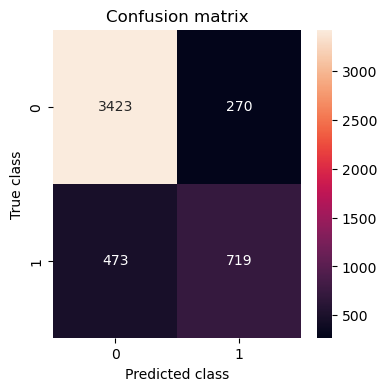

In [172]:
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix,annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

Canto Superior Esquerdo	Verdadeiros Negativos (TN)	O modelo previu Negativo e o real era Negativo. (Acertos na Classe 0)

Canto Inferior Direito	Verdadeiros Positivos (TP)	O modelo previu Positivo e o real era Positivo. (Acertos na Classe 1)

Canto Superior Direito	Falsos Positivos (FP)	O modelo previu Positivo, mas o real era Negativo. (Erros Tipo I)

Canto Inferior Esquerdo	Falsos Negativos (FN)	O modelo previu Negativo, mas o real era Positivo. (Erros Tipo II)

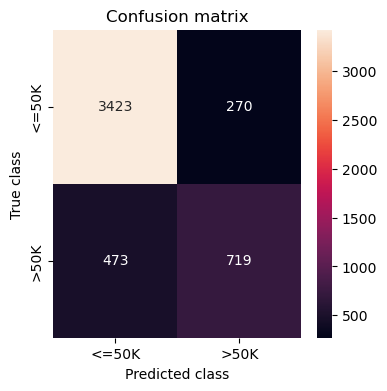

In [176]:
LABELS =  ['<=50K', '>50K'] 

plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [179]:
# LABELS =  ['>50K','<=50K']

# plt.figure(figsize=(4, 4))
# sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
# plt.title("Confusion matrix")
# plt.ylabel('True class')
# plt.xlabel('Predicted class')
# plt.show()

In [183]:
import numpy as np
# Obtém os valores únicos e ordenados presentes no conjunto de teste
classes_ordenadas = np.unique(y_census_teste_extra)
print(f"Classes na ordem: {classes_ordenadas}") # nomear a coluna correta


Classes na ordem: [' <=50K' ' >50K']


In [173]:
y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      shape=(32561,), dtype=object)

In [175]:
previsoes


array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      shape=(4885,), dtype=object)